# Objectif du notebook 

Date de création : 20/01/2025

Notebook a run pour mettre en forme les données de la campagne Fiberscope Groix 2025 :

* Données AIS 
* Données GPS 
* Données SBE OBS 
* Fond de carte bathy pour les représentations 

In [1]:
import os
import sys
import numpy as np
import pandas as pd

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_rhumrum_data = os.path.join(project_root, "data", "rhumrum")
root_rhumrum_metadata = os.path.join(root_rhumrum_data, "metadata")
root_rhumrum_ais = os.path.join(root_rhumrum_data, "ais")
if not os.path.exists(root_rhumrum_ais):
    os.makedirs(root_rhumrum_ais)

root_bathy_data = os.path.join(project_root, "data", "bathy")

ais_fpath = os.path.join(root_rhumrum_ais, "extract-ais-pos-for-zone-ecole-navale-by-month-201305.csv"
)

# Current folder
root_folder = os.path.join(project_root, "real_data_analysis", "rhumrum")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [3]:
sys.path.append(project_root)

from real_data_analysis.rhumrum.src.data_preprocessing.preprocess_utils import (
    load_obs_pos_wgs84,
    transform_pos_wgs84_enu,
    # plot_SBE39_obs,
    # plot_SBE37_sounding,
    plot_bathy,
    # build_SBE39_obs_dataset,
    # build_oceano_src_dataset,
    # build_SBE37_sounding_dataset,
    build_AIS_dataset,
    # build_GPS_dataset,
    build_BATHY_dataset,
)

In [4]:
# sbe37_data_folder = os.path.join(root_groix_data, "SBE37_SOUNDING")
# interpolation_time_step = "30s"
# ds_SBE = build_SBE37_sounding_dataset(
#     sbe_data_folder=sbe37_data_folder,
#     interpolation_time_step=interpolation_time_step,
# )

# Positions des OBS

In [5]:
obs_pos_wgs84 =  load_obs_pos_wgs84(root_metadata=root_rhumrum_metadata)

In [6]:
obs_pos_wgs84

,lon,lat,h
id,,,
RR41,65.3344,-27.7330,-5430.0
RR43,65.5826,-27.5338,-4264.0
RR44,65.7481,-27.5324,-4548.0
RR47,65.7553,-27.6958,-4582.0


In [7]:
# Coordonnées de le l'origine du repère de référence
obs_pos_id = "RR47"
pos0 = obs_pos_wgs84.loc[obs_pos_id]
lat0 = pos0.lat
lon0 = pos0.lon
h0 = pos0.h

local_frame_origin = {
    "id": obs_pos_id,
    "lat": lat0,
    "lon": lon0,
    "h": h0,
}

In [8]:
transform_pos_wgs84_enu(obs_pos_wgs84, local_frame_origin)

(array([-41466.42599908, -17048.21775936,   -710.73215582,      0.        ]),
 array([-4189.57667054, 17927.72774208, 18093.8706272 ,     0.        ]),
 array([-984.19547469,  269.88895767,    8.15984878,    0.        ]))

# Données bathy pour le fond de carte 

La zone sélectionnée est une zone de 0.25° x 0.25° soit environ 37.56 km x 55.6 km 

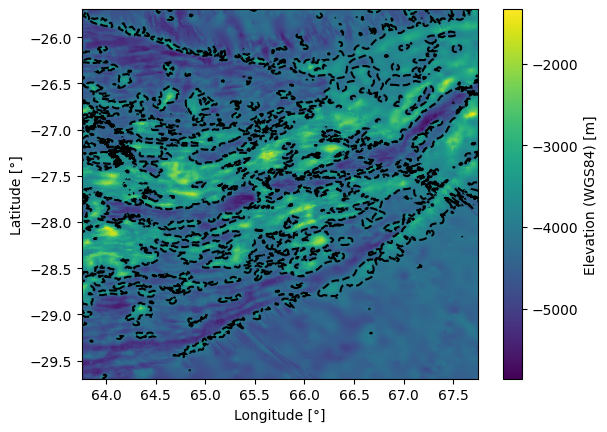

In [19]:
ds_bathy = build_BATHY_dataset(local_frame_origin, root_bathy_data=root_bathy_data, dlat_box=2, dlon_box=2)
plot_bathy(ds_bathy, contour_levels=[-4000])

# Données GPS / AIS  

In [10]:
time_step = "60s"  # 10 seconds
# t_start = pd.Timestamp("2013-05-01 00:18:26", tz="UTC")     # Min AIS 
# t_end = pd.Timestamp("2013-05-31 23:55:14", tz="UTC")       # Max AIS

In [11]:
ds_ais = build_AIS_dataset(
    local_frame_origin=local_frame_origin,
    # t_start=t_start,
    # t_end=t_end,
    interpolation_time_step=time_step,
    ais_fpath=ais_fpath,
    root_metadata=root_rhumrum_metadata,
)


Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%

In [12]:
ds_ais

<xarray.Dataset> Size: 4GB
Dimensions:  (mmsi: 1783, time: 44617)
Coordinates:
  * mmsi     (mmsi) int32 7kB 215163000 310479000 ... 636015790 636090284
  * time     (time) datetime64[ns] 357kB 2013-05-01T00:19:00 ... 2013-05-31T2...
Data variables:
    lon      (mmsi, time) float32 318MB nan nan nan nan nan ... nan nan nan nan
    lat      (mmsi, time) float32 318MB nan nan nan nan nan ... nan nan nan nan
    e        (mmsi, time) float64 636MB nan nan nan nan nan ... nan nan nan nan
    n        (mmsi, time) float64 636MB nan nan nan nan nan ... nan nan nan nan
    u        (mmsi, time) float64 636MB nan nan nan nan nan ... nan nan nan nan
    v_e      (mmsi, time) float64 636MB nan nan nan nan nan ... nan nan nan nan
    v_n      (mmsi, time) float64 636MB nan nan nan nan nan ... nan nan nan nan
    v_u      (mmsi, time) float64 636MB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/33)
    description:                   Positions AIS interpolées
    interpolation_time_step:       60s
    campagne:                      RHUM SWIR
    geodesic_frame:                WGS84
    local_frame:                   ENU
    local_frame_origin:            RR47
    ...                            ...
    RR44_e_apriori:                -710.7321558157346
    RR44_n_apriori:                18093.870627204033
    RR44_u_apriori:                8.159848783511734
    RR47_e_apriori:                0.0
    RR47_n_apriori:                0.0
    RR47_u_apriori:                0.0

# Sauvergarde de l'ensemble des données au format NETCDF

In [14]:
# Save datasets to netcdf files
ds_ais.to_netcdf(os.path.join(data_folder, "ais.nc"))
ds_bathy.to_netcdf(os.path.join(data_folder, "bathy.nc"))


# Données OBS 